# FoundationStereo TensorRT · 800 × 960 real-scale 3D reconstruction

This notebook rectifies one saved stereo capture, resizes the RGB pair to the fixed `800 × 960` TensorRT engine input, and runs `foundationstereo_800x960.engine`. All 3D projection, filtering, and mesh construction then remain at **800 × 960**; the disparity is not upsampled to the original image grid.

**Scale contract:** scale the original rectified intrinsics into the model grid: `fx_model = fx_original / (W_original / 960)`, `fy_model = fy_original / (H_original / 800)`, with the same scaling for `cx` and `cy`. Then `Z = fx_model × baseline / d_engine` produces the same physical depth as projecting an upsampled disparity in the original grid. The rectified mask is resized with nearest-neighbour interpolation, so only mask-selected model pixels can enter the point cloud and mesh.

## 1. Environment and TensorRT engine

In [10]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from time import perf_counter
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorrt as trt
import torch

from fs_high_resolution_utils import (
    build_constrained_mesh,
    configure_capture,
    load_rectify_and_select_mask,
    postprocess_disparity_gpu,
    save_triangle_mesh,
    show_rectified_selection,
)

REPO_ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents)
     if (candidate / 'FoundationStereo').is_dir() and (candidate / 'onnx').is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError('Open this notebook from the FS_Engine repository or python/ directory.')
REPO_ROOT = REPO_ROOT.resolve()
ENGINE_PATH = REPO_ROOT / 'onnx' / 'foundationstereo_800x960.engine'
MODEL_HEIGHT, MODEL_WIDTH = 800, 960
DEVICE = torch.device('cuda:0')

if not torch.cuda.is_available():
    raise RuntimeError('PyTorch CUDA is required.')
if not ENGINE_PATH.is_file():
    raise FileNotFoundError(f'Engine not found: {ENGINE_PATH}')

print('Repository:', REPO_ROOT)
print('Engine:', ENGINE_PATH)
print('TensorRT:', trt.__version__)
print('PyTorch:', torch.__version__, '| CUDA:', torch.version.cuda)
print('GPU:', torch.cuda.get_device_name(DEVICE))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Repository: /home/liu4000/Desktop/FS_Engine
Engine: /home/liu4000/Desktop/FS_Engine/onnx/foundationstereo_800x960.engine
TensorRT: 11.2.1.2
PyTorch: 2.13.0+cu132 | CUDA: 13.2
GPU: NVIDIA RTX PRO 4000 Blackwell


## 2. Select, rectify, and validate one stereo capture

Capture: /home/liu4000/Desktop/FS_Engine/data/Volunteer2_lower/0
Rectified: 2448×2048, fx=1723.58, baseline=0.055079 m


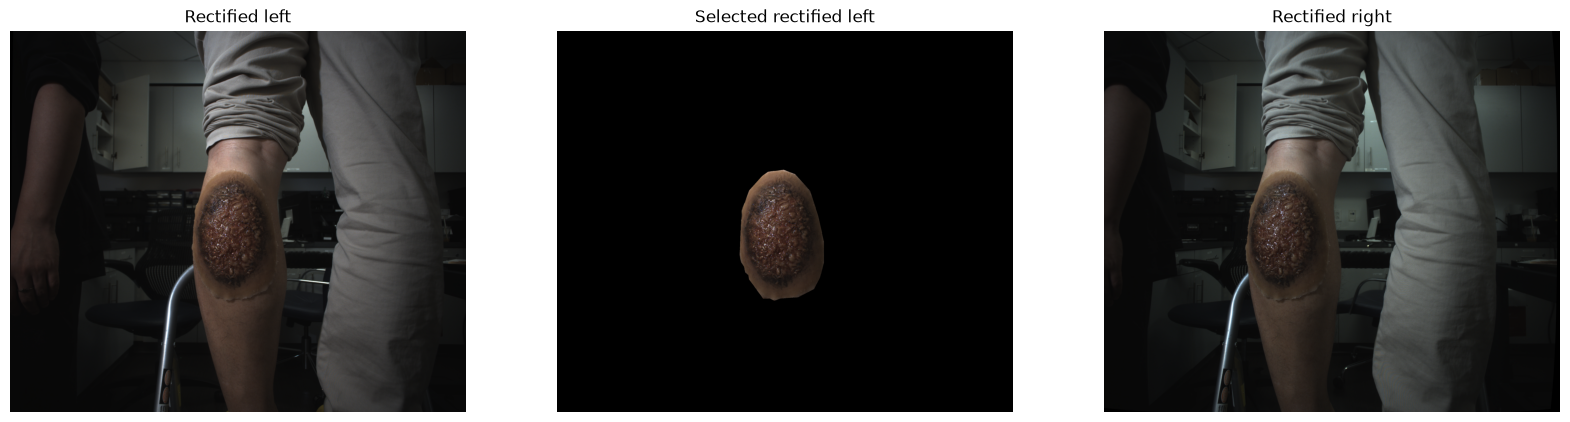

In [11]:
CAPTURE_DIR = configure_capture(globals(), REPO_ROOT)
rectified_left, rectified_right, rectified_K, baseline_m, rectified_left_mask = load_rectify_and_select_mask(
    globals(), LEFT_PATH, RIGHT_PATH, LEFT_MASK_PATH, CALIBRATION_PATH, EXPECTED_WIDTH, EXPECTED_HEIGHT
)
ORIGINAL_HEIGHT, ORIGINAL_WIDTH = rectified_left.shape[:2]
assert rectified_right.shape[:2] == (ORIGINAL_HEIGHT, ORIGINAL_WIDTH)
assert rectified_left_mask.shape == (ORIGINAL_HEIGHT, ORIGINAL_WIDTH)
print(f'Capture: {CAPTURE_DIR}')
print(f'Rectified: {ORIGINAL_WIDTH}×{ORIGINAL_HEIGHT}, fx={rectified_K[0, 0]:.2f}, baseline={baseline_m:.6f} m')
show_rectified_selection(rectified_left, rectified_left_mask, rectified_right)

## 3. Load the fixed-shape TensorRT engine

In [12]:
class FoundationStereoTensorRT:
    INPUT_NAMES = ('left', 'right')
    OUTPUT_NAME = 'disp'

    def __init__(self, engine_path: Path, height: int, width: int):
        self.height, self.width = height, width
        self.logger = trt.Logger(trt.Logger.WARNING)
        self.runtime = trt.Runtime(self.logger)
        self.engine = self.runtime.deserialize_cuda_engine(engine_path.read_bytes())
        if self.engine is None:
            raise RuntimeError(f'Could not deserialize {engine_path}')
        self.context = self.engine.create_execution_context()
        self.stream = torch.cuda.Stream(device=DEVICE)
        if self.context is None:
            raise RuntimeError('Could not create a TensorRT execution context')
        self.tensor_names = tuple(self.engine.get_tensor_name(i) for i in range(self.engine.num_io_tensors))
        expected_names = set(self.INPUT_NAMES) | {self.OUTPUT_NAME}
        if set(self.tensor_names) != expected_names:
            raise RuntimeError(f'Unexpected engine I/O: {self.tensor_names}')
        expected_input_shape = (1, 3, height, width)
        for name in self.INPUT_NAMES:
            if not self.context.set_input_shape(name, expected_input_shape):
                raise RuntimeError(f'Unable to set {name} shape to {expected_input_shape}')
        output_shape = tuple(self.context.get_tensor_shape(self.OUTPUT_NAME))
        if output_shape != (1, 1, height, width):
            raise RuntimeError(f'Unexpected output shape: {output_shape}')
        print('Engine I/O:', self.tensor_names)
        print('Input shape:', expected_input_shape, '| Output shape:', output_shape)

    def _to_device_tensor(self, image_rgb: np.ndarray) -> torch.Tensor:
        resized = cv2.resize(image_rgb, (self.width, self.height), interpolation=cv2.INTER_LINEAR)
        nchw = np.ascontiguousarray(resized.transpose(2, 0, 1)[None].astype(np.float32))
        return torch.from_numpy(nchw).to(DEVICE, non_blocking=True)

    def infer(self, left_rgb: np.ndarray, right_rgb: np.ndarray):
        # Keep tensor preparation and TensorRT execution on one non-default CUDA stream.
        with torch.cuda.stream(self.stream):
            left = self._to_device_tensor(left_rgb)
            right = self._to_device_tensor(right_rgb)
            disparity = torch.empty((1, 1, self.height, self.width), device=DEVICE, dtype=torch.float32)
            self.context.set_tensor_address('left', left.data_ptr())
            self.context.set_tensor_address('right', right.data_ptr())
            self.context.set_tensor_address('disp', disparity.data_ptr())
            if not self.context.execute_async_v3(self.stream.cuda_stream):
                raise RuntimeError('TensorRT enqueue failed')
        return disparity, left, right

runner = FoundationStereoTensorRT(ENGINE_PATH, MODEL_HEIGHT, MODEL_WIDTH)

[08/28/2026-16:41:36] [TRT] [W] WARNING The logger passed into createInferRuntime differs from one already registered for an existing builder, runtime, or refitter. So the current new logger is ignored, and TensorRT will use the existing one which is returned by nvinfer1::getLogger() instead.
Engine I/O: ('left', 'right', 'disp')
Input shape: (1, 3, 800, 960) | Output shape: (1, 1, 800, 960)


## 4. Engine inference and latency

In [13]:
WARMUP_RUNS, BENCHMARK_RUNS = 2, 5

for _ in range(WARMUP_RUNS):
    warmup_disp, _, _ = runner.infer(rectified_left, rectified_right)
torch.cuda.synchronize(DEVICE)
del warmup_disp

latencies_ms = []
model_disparity = None
left_model = right_model = None
for _ in range(BENCHMARK_RUNS):
    started = torch.cuda.Event(enable_timing=True)
    finished = torch.cuda.Event(enable_timing=True)
    with torch.cuda.stream(runner.stream):
        started.record(runner.stream)
        model_disparity, left_model, right_model = runner.infer(rectified_left, rectified_right)
        finished.record(runner.stream)
    finished.synchronize()
    latencies_ms.append(started.elapsed_time(finished))

model_disparity_800x960 = np.ascontiguousarray(model_disparity.squeeze().detach().cpu().numpy(), dtype=np.float32)
assert model_disparity_800x960.shape == (MODEL_HEIGHT, MODEL_WIDTH)
if not np.isfinite(model_disparity_800x960).all():
    raise RuntimeError('TensorRT returned non-finite disparity values')

print(f'TensorRT mean latency: {np.mean(latencies_ms):.2f} ms')
print(f'TensorRT p50 / p90: {np.percentile(latencies_ms, 50):.2f} / {np.percentile(latencies_ms, 90):.2f} ms')
print(f'Output: {model_disparity_800x960.shape}, min={model_disparity_800x960.min():.3f}, max={model_disparity_800x960.max():.3f}')

TensorRT mean latency: 585.31 ms
TensorRT p50 / p90: 583.98 / 587.73 ms
Output: (800, 960), min=11.345, max=98.430


## 5. Keep projection on the 800 × 960 model grid

The engine output remains at `800 × 960`. To preserve real 3D scale without upsampling the disparity, the original rectified intrinsics are transformed into this resized pixel coordinate system. Disparity is horizontal, but both x and y intrinsic rows must be scaled because XYZ uses resized image coordinates.

The original rectified mask is resized with nearest-neighbour interpolation. Only selected pixels from this mask are retained in subsequent 3D processing.

Resize factors: x=2.550000, y=2.560000
Original fx/fy: 1723.5797 1723.5797
Model-grid fx/fy: 675.91364 673.2733
Disparity stays in 800×960 pixels; XYZ uses the scaled model-grid K.
Engine disparity: /home/liu4000/Desktop/FS_Engine/result/Volunteer2_lower/0/tensorrt_disparity_800x960.npy


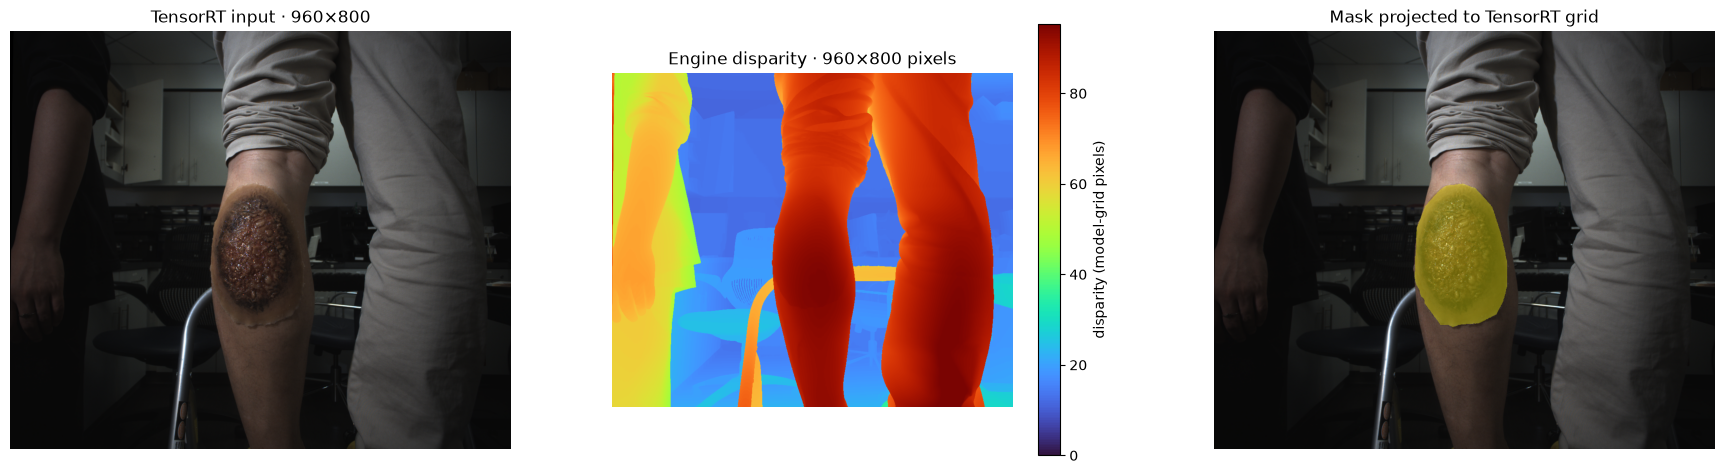

In [8]:
scale_x = ORIGINAL_WIDTH / MODEL_WIDTH
scale_y = ORIGINAL_HEIGHT / MODEL_HEIGHT
rectified_K_model = rectified_K.copy().astype(np.float32)
rectified_K_model[0, :] /= scale_x
rectified_K_model[1, :] /= scale_y
rectified_K_model[2, :] = (0.0, 0.0, 1.0)

model_left_rgb = cv2.resize(rectified_left, (MODEL_WIDTH, MODEL_HEIGHT), interpolation=cv2.INTER_LINEAR)
model_mask = cv2.resize(
    rectified_left_mask.astype(np.uint8), (MODEL_WIDTH, MODEL_HEIGHT), interpolation=cv2.INTER_NEAREST
).astype(bool)
assert model_left_rgb.shape == (MODEL_HEIGHT, MODEL_WIDTH, 3)
assert model_mask.shape == (MODEL_HEIGHT, MODEL_WIDTH)

print(f'Resize factors: x={scale_x:.6f}, y={scale_y:.6f}')
print('Original fx/fy:', rectified_K[0, 0], rectified_K[1, 1])
print('Model-grid fx/fy:', rectified_K_model[0, 0], rectified_K_model[1, 1])
print('Disparity stays in 800×960 pixels; XYZ uses the scaled model-grid K.')

finite = model_disparity_800x960[np.isfinite(model_disparity_800x960) & (model_disparity_800x960 > 0)]
display_limit = float(np.percentile(finite, 99)) if finite.size else 1.0
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
axes[0].imshow(model_left_rgb)
axes[0].set_title('TensorRT input · 960×800')
axes[1].imshow(model_disparity_800x960, cmap='turbo', vmin=0, vmax=display_limit)
axes[1].set_title('Engine disparity · 960×800 pixels')
axes[2].imshow(model_left_rgb)
axes[2].imshow(np.where(model_mask, 1.0, np.nan), cmap='spring', alpha=0.35, vmin=0, vmax=1)
axes[2].set_title('Mask projected to TensorRT grid')
for axis in axes:
    axis.axis('off')
fig.colorbar(axes[1].images[0], ax=axes[1], shrink=0.8, label='disparity (model-grid pixels)')
plt.show()

## 6. Real-scale XYZ, full-resolution model-grid mesh, and area

Only valid points inside the resized mask are projected. `downsample_pixels=1` deliberately keeps every retained `800 × 960` model-grid pixel: this is **not** an original-resolution mesh and performs no additional downsampling. It can be memory- and CPU-intensive for large masks. The final persistent output is only the colored mesh PLY.

In [9]:
Z_FAR_M = 1.0
REMOVE_INVISIBLE, DENOISE_CLOUD = True, True
DENOISE_MAX_NEIGHBOR_DISTANCE_M = 0.01
DENOISE_MIN_NEIGHBORS, DENOISE_EDGE_MIN_NEIGHBORS = 3, 2

# No upsample: disparity, K, image, and mask all stay on the 800×960 model grid.
disparity_cuda = torch.from_numpy(model_disparity_800x960).to(DEVICE, non_blocking=True)
surface = postprocess_disparity_gpu(
    disparity_cuda, rectified_K_model, baseline_m, model_mask, DEVICE, Z_FAR_M,
    remove_invisible=REMOVE_INVISIBLE,
    denoise=DENOISE_CLOUD,
    max_neighbor_distance_m=DENOISE_MAX_NEIGHBOR_DISTANCE_M,
    min_neighbors=DENOISE_MIN_NEIGHBORS,
    edge_min_neighbors=DENOISE_EDGE_MIN_NEIGHBORS,
)
valid_xyz = surface.xyz_map[surface.keep_mask]
if len(valid_xyz) == 0:
    raise RuntimeError('No valid masked points survived filtering')
depth_range = valid_xyz[:, 2].amin().item(), valid_xyz[:, 2].amax().item()
print(f'Masked retained points: {len(valid_xyz):,} | depth range: {depth_range[0]:.4f}–{depth_range[1]:.4f} m')

# Build the constrained mesh from every retained 800×960-grid mask point: no downsampling.
DOWNSAMPLE_PIXELS = 1
MESH_MAX_EDGE_M = 0.02
MESH_MAX_DEPTH_JUMP_M = 0.01
mesh_result = build_constrained_mesh(
    surface.xyz_map, surface.keep_mask, model_mask, model_left_rgb,
    downsample_pixels=DOWNSAMPLE_PIXELS,
    max_edge_m=MESH_MAX_EDGE_M,
    max_depth_jump_m=MESH_MAX_DEPTH_JUMP_M,
)
mesh_path = POINT_CLOUD_DIR / 'tensorrt_800x960_real_scale_mesh.ply'
save_triangle_mesh(mesh_result, mesh_path)
print(f'Area: {mesh_result.area_m2:.6f} m² ({mesh_result.area_m2 * 1e4:.2f} cm²)')
print(f'Vertices: {len(mesh_result.vertices):,} | triangles: {len(mesh_result.triangles):,}')
print(f'Saved full 800×960-grid mesh: {mesh_path}')

Masked retained points: 38,668 | depth range: 0.3926–0.4587 m
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Area: 0.018694 m² (186.94 cm²)
Vertices: 38,668 | triangles: 76,658
Saved full 800×960-grid mesh: /home/liu4000/Desktop/FS_Engine/result/Volunteer2_lower/0/tensorrt_800x960_real_scale_mesh.ply
